In [47]:
import python_files.ImageDeconvolution as iD
import python_files.ImageFFT as ifft
import python_files.imageForms as IF
import matplotlib.pyplot as plt
import numpy as np
import cv2 as cv

Ex 1

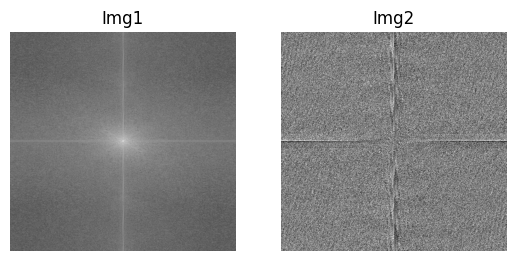

In [48]:
doggo = cv.imread("Aula_8_files/aula8_1.bmp")
doggo_gray = cv.cvtColor(doggo, cv.COLOR_BGR2GRAY)
mag_doggo_gray, phase_doggo_gray = ifft.GetFFT_Mag_Phase(doggo_gray)

IF.showSideBySideImages(np.fft.fftshift(cv.log(mag_doggo_gray)), np.fft.fftshift(phase_doggo_gray), 'FFT')

Ex 2

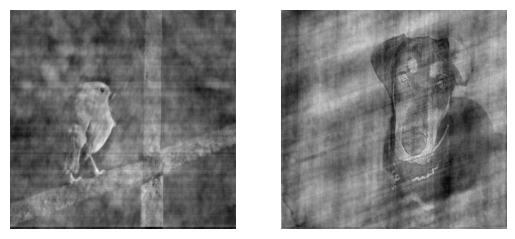

In [49]:
birdy = cv.imread("Aula_8_files/aula8_2.bmp")
birdy_gray2 = cv.cvtColor(birdy, cv.COLOR_BGR2GRAY)
mag_birdy_gray2, phase_birdy_gray = ifft.GetFFT_Mag_Phase(birdy_gray2)

new_img = ifft.GetFFT_Inverse_Mag_Phase(mag_doggo_gray, phase_birdy_gray)
new_img2 = ifft.GetFFT_Inverse_Mag_Phase(mag_birdy_gray2, phase_doggo_gray)

plt.subplot(1, 2, 1)
plt.imshow(new_img, 'gray')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(new_img2, 'gray')
plt.axis('off')
plt.show()

Ex 3

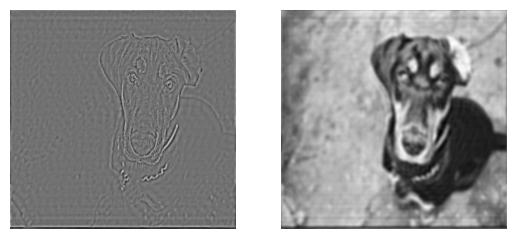

In [50]:
mask_LP = ifft.CreateFilterMask_Ideal(mag_doggo_gray.shape, 40, False)
mask_HP = ifft.CreateFilterMask_Ideal(mag_doggo_gray.shape, 40, True)

output_LP = mag_doggo_gray.copy()
output_HP = mag_doggo_gray.copy()

cv.multiply(mag_doggo_gray, np.fft.fftshift(mask_LP), output_LP)
cv.multiply(mag_doggo_gray, np.fft.fftshift(mask_HP), output_HP)

phase_doggo_gray_LP = phase_doggo_gray.copy()
phase_doggo_gray_HP = phase_doggo_gray.copy()

new_img2 = ifft.GetFFT_Inverse_Mag_Phase(output_LP, phase_doggo_gray_LP)
new_img = ifft.GetFFT_Inverse_Mag_Phase(output_HP, phase_doggo_gray_HP)

plt.subplot(1, 2, 1)
plt.imshow(new_img, 'gray')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(new_img2, 'gray')
plt.axis('off')
plt.show()

Ex 4

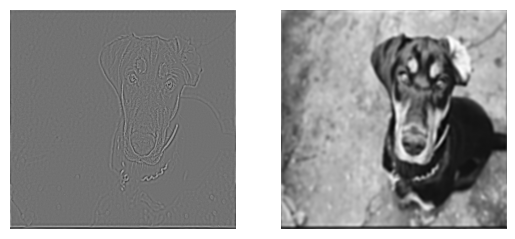

In [51]:
mask_LP = ifft.CreateFilterMask_Gaussian(mag_doggo_gray.shape, 40, False)
mask_HP = ifft.CreateFilterMask_Gaussian(mag_doggo_gray.shape, 40, True)

output_LP = mag_doggo_gray.copy()
output_HP = mag_doggo_gray.copy()

cv.multiply(mag_doggo_gray, np.fft.fftshift(mask_LP), output_LP)
cv.multiply(mag_doggo_gray, np.fft.fftshift(mask_HP), output_HP)

phase_doggo_gray_LP = phase_doggo_gray.copy()
phase_doggo_gray_HP = phase_doggo_gray.copy()

new_img2 = ifft.GetFFT_Inverse_Mag_Phase(output_LP, phase_doggo_gray_LP)
new_img = ifft.GetFFT_Inverse_Mag_Phase(output_HP, phase_doggo_gray_HP)

plt.subplot(1, 2, 1)
plt.imshow(new_img, 'gray')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(new_img2, 'gray')
plt.axis('off')
plt.show()

Ex 5

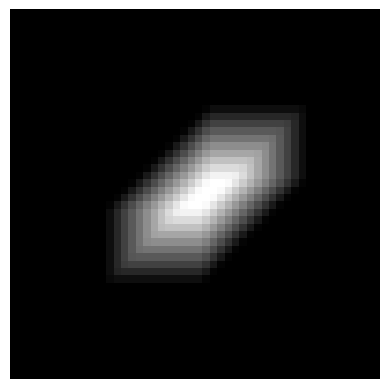

In [52]:
square = cv.imread("Aula_8_files/aula8_3.bmp", 0)
filter = iD.GetFilterConv(True, 10)
bad_vision_square = cv.filter2D(square, cv.CV_8U, filter, anchor=(np.int32(filter.shape[0]/2), np.int32(filter.shape[1]/2)))
plt.imshow(bad_vision_square, 'gray')
plt.axis('off')
plt.show() 

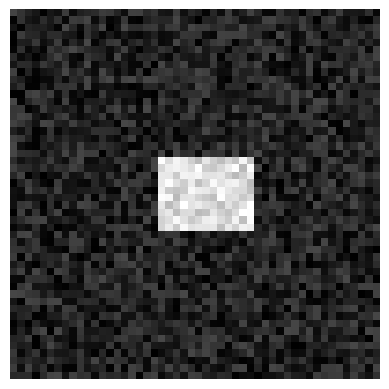

In [86]:
noiseAmp = float(input("Noise Amplitude PLS: "))
attomic_bomb_filter = np.random.rand(square.shape[0], square.shape[1]) * noiseAmp
noisy_square = square + attomic_bomb_filter
plt.imshow(noisy_square, 'gray')
plt.axis('off')
plt.show()

Ex 8

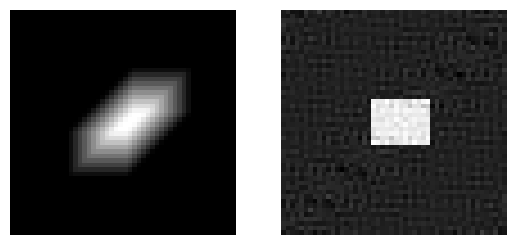

In [95]:
square_restored = iD.InverseDeconvolutionWiener(bad_vision_square, 0.0000001 , True, 1)

plt.subplot(1, 2, 1)
plt.imshow(bad_vision_square, 'gray')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(square_restored, 'gray')
plt.axis('off')
plt.show()

Ex 7

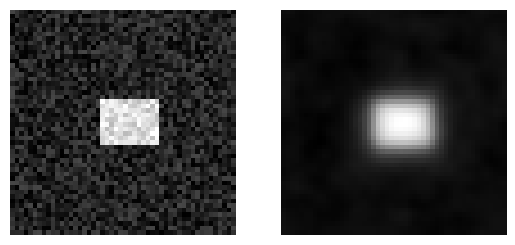

In [87]:
square_restored = iD.InverseDeconvolutionWiener(noisy_square, 0.5 , False, 1)

plt.subplot(1, 2, 1)
plt.imshow(noisy_square, 'gray')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(square_restored, 'gray')
plt.axis('off')
plt.show()